# $\text{AR}(1)$ with Offset

$\text{AR}(1)$ with a constant offset is defined by,

$
\begin{equation}
X_t = \varphi X_{t-1} + \mu^* + \sigma \varepsilon_t
\end{equation}
\tag{1}
$

where, $\varepsilon \sim \text{Normal}(0,1)$

The stationarity requires $\lvert \varphi \rvert < 1$. The stationary mean and variance are given by,

$
\begin{align}
&\lim_{t \to \infty} \text{E}(X_t) = \frac{\mu^*}{1 - \varphi} \\
&\lim_{t \to \infty} \text{Var}(X_t) = \frac{\sigma^2}{1 - \varphi^2}
\end{align}
\tag{2}
$

It follows that $X_t$ has distribution,

$
\begin{align}
X_t \sim \text{Normal}\left(  \frac{\mu}{1 - \varphi} ,  \frac{\sigma^2}{1 - \varphi^2} \right)
\end{align}
\tag{3}
$

## Imports

In [33]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.plots import stack, fcurve, PlotType, curve
from lib.data import arima, stats
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [34]:
σ = 1.0
nsample = 1000

def cumu_mean_plot(φ, σ, μ, nsample):
    title = f"Convergence of Simulation Mean to $t\\rightarrow\infty$ Limit:  $\\phi=${φ}, $\\sigma=${σ}, $\\mu^*=${μ}"
    t, ar = arima.create_ar_offset_source(φ=[φ], σ=σ, μ=μ, npts=nsample)
    _, cumu_mean = stats.compute_cumu_mean(t, ar)
    _, ar_mean = arima.compute_ar1_offset_mean(φ=φ, μ=μ, npts=len(t))
    fcurve(data=cumu_mean, func=ar_mean, x=t, fx=t, title_offset=0.025, plot_axis_type=PlotType.XLOG, xlabel=r"$t$", ylabel=r"$\mu_t$",
           labels=["Simulation", r"$\mu_t\rightarrow \frac{\mu^*}{1 - \varphi}$"], title=title)
    
def cumu_sd_plot(φ, σ, μ, nsample):
    title = f"Convergence of Simulation Standard Deviation to $t\\rightarrow\infty$ Limit: $\\phi=${φ}, $\\sigma=${σ}, $\\mu^*=${μ}"
    t, ar = arima.create_ar_offset_source(φ=[φ], σ=σ, μ=μ, npts=nsample)
    _, cumu_sd = stats.compute_cumu_sd(t, ar)
    _, ar_sd = arima.compute_ar1_offset_sd(npts=len(t), φ=φ, σ=σ)
    fcurve(data=cumu_sd, func=ar_sd, x=t, fx=t, title_offset=0.025, plot_axis_type=PlotType.XLOG, xlabel=r"$t$", ylabel=r"$\sigma_t$",
           labels=["Simulation", r"$\sigma_t\rightarrow\sqrt{\frac{\sigma^2}{1-\varphi^2}}$"], title=title)
        
def comparison_plot_μ(μ_vals, ylim, title, *params):
    labels = [r"$μ^*=$" + f"{val}" for val in μ_vals]
    ylabels = r"$S_t$"
    source = lambda **kwargs : arima.create_ar_offset_source(**kwargs)
    t, scan = create_parameter_scan(source, *params)
    stack(scan, t, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel=r"$t$", figsize=(10, 6), lw=1)
    
def comparison_plot_φ(φ_vals, ylim, title, *params):
    labels = [f"φ={val}" for val in φ_vals] 
    ylabels = r"$S_t$"
    source = lambda **kwargs : arima.create_ar_offset_source(**kwargs)
    t, scan = create_parameter_scan(source, *params)
    stack(scan, t, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel=r"$t$", figsize=(10, 6), lw=1)


## Simulation $\varphi$ Scan

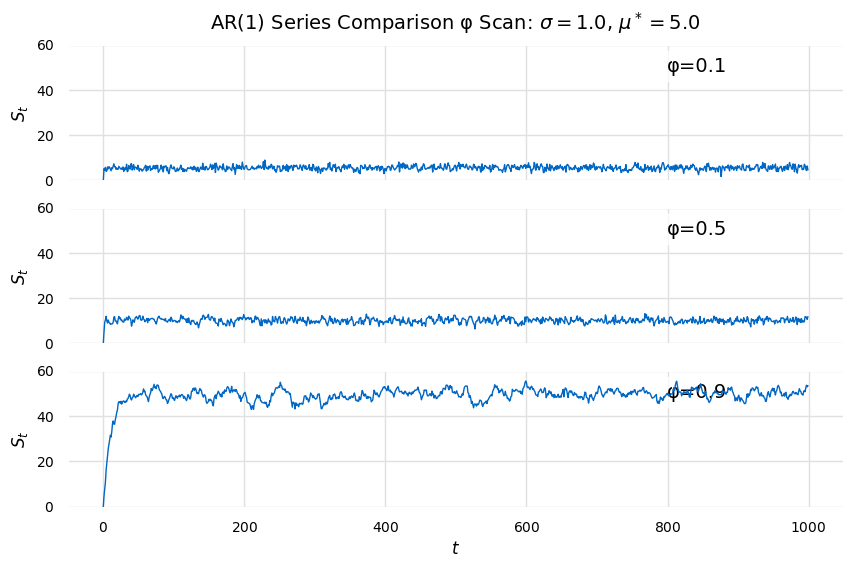

In [35]:
μ = 5.0
title = f"AR(1) Series Comparison φ Scan: $σ={{{σ}}}$, $μ^*={{{μ}}}$"
φ_vals = [0.1, 0.5, 0.9]
params = [{"φ": [φ], "σ": σ, "μ": μ, "npts": nsample} for φ in φ_vals]
comparison_plot_φ(φ_vals, [0.0, 60.0], title, *params)

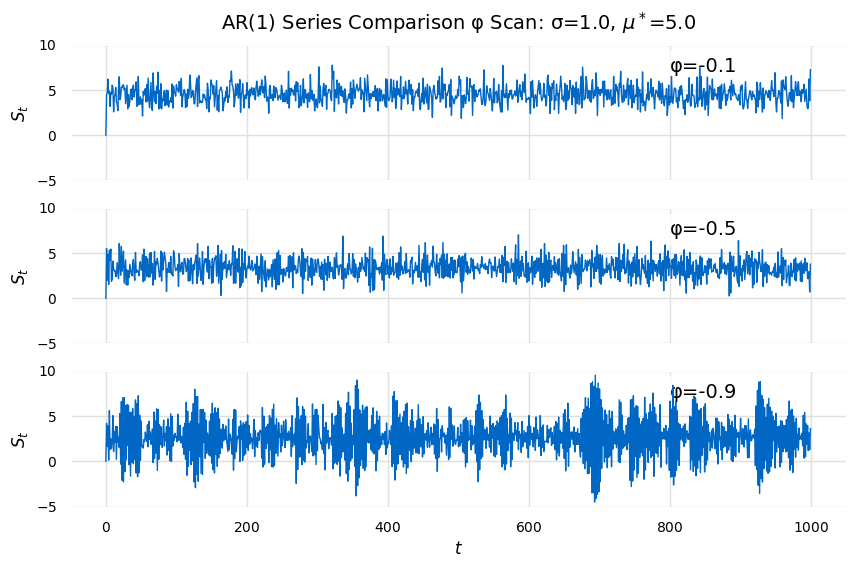

In [36]:
μ = 5.0
title = f"AR(1) Series Comparison φ Scan: σ={σ}, " + r"$μ^*$=" + f"{μ}"
φ_vals = [-0.1, -0.5, -0.9]
params = [{"φ": [φ], "σ": σ, "μ": μ, "npts": nsample} for φ in φ_vals]
comparison_plot_φ(φ_vals, [-5.0, 10.0], title, *params)

## Simulation $\mu^*$ Scan

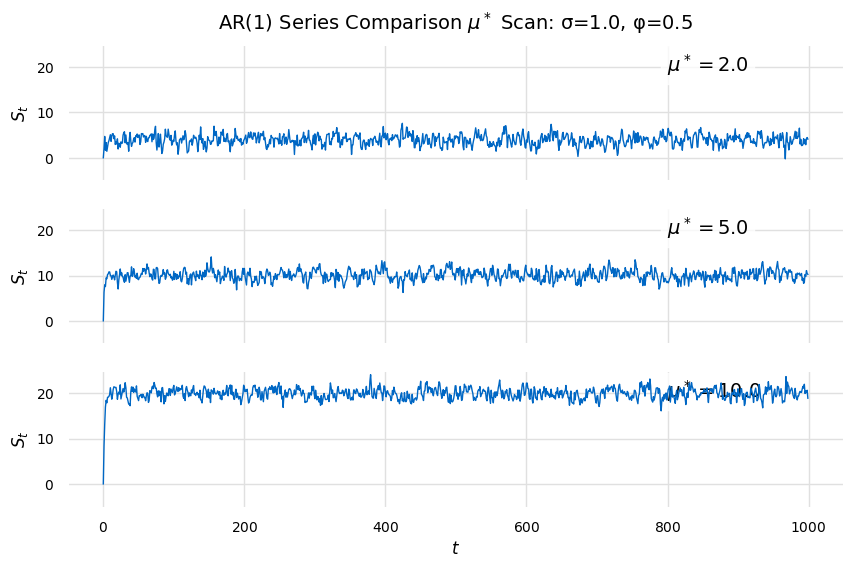

In [37]:
φ = 0.5
title = f"AR(1) Series Comparison " + r"$\mu^*$" + f" Scan: σ={σ}, φ={φ}"
μ_vals = [2.0, 5.0, 10.0]
params = [{"φ": [φ], "σ": σ, "μ": μ, "npts": nsample} for μ in μ_vals]
comparison_plot_μ(μ_vals, [-5.0, 25.0], title, *params)

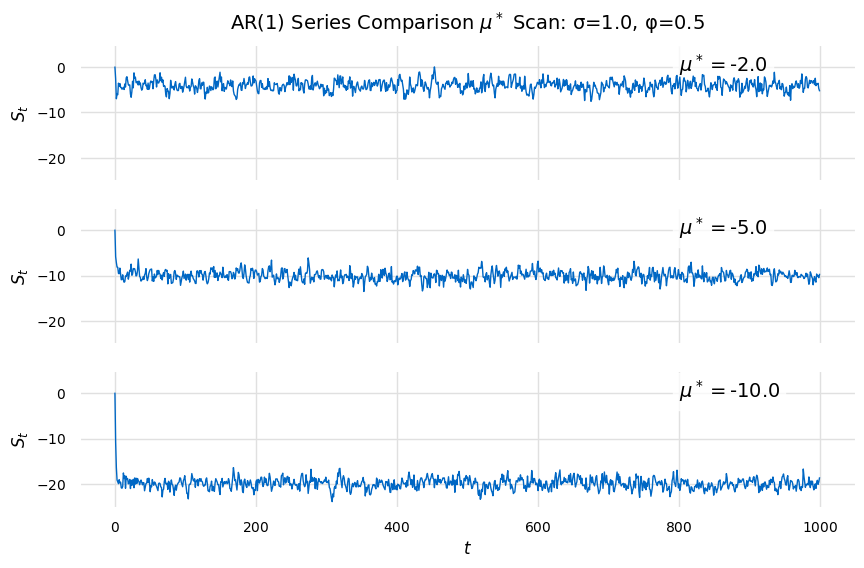

In [38]:
title = f"AR(1) Series Comparison " + r"$\mu^*$" + f" Scan: σ={σ}, φ={φ}"
μ_vals = [-2.0, -5.0, -10.0]
params = [{"φ": [φ], "σ": σ, "μ": μ, "npts": nsample} for μ in μ_vals]
comparison_plot_μ(μ_vals, [-25.0, 5.0], title, *params)

## Mean

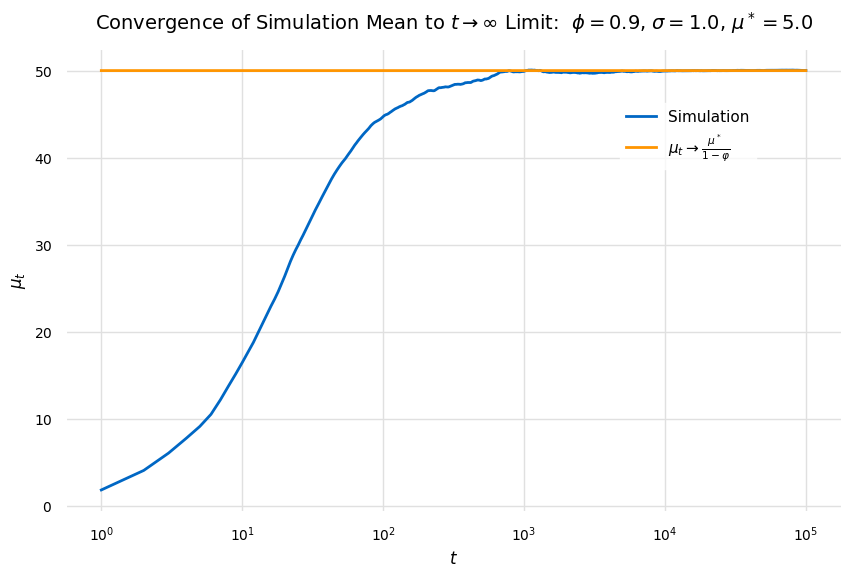

In [39]:
φ = 0.9
μ = 5.0
nsample = 100000
cumu_mean_plot(φ, σ, μ, nsample)

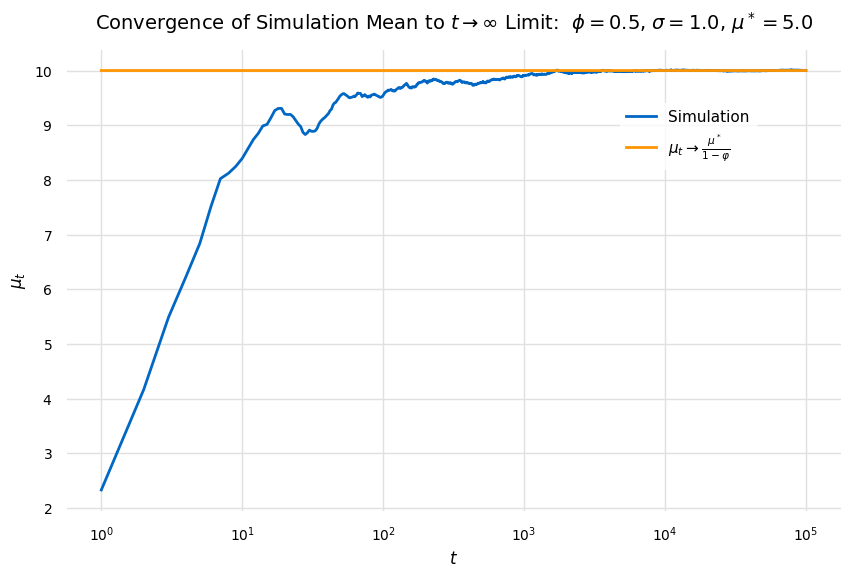

In [40]:
φ = 0.5
μ = 5.0
nsample = 100000
cumu_mean_plot(φ, σ, μ, nsample)

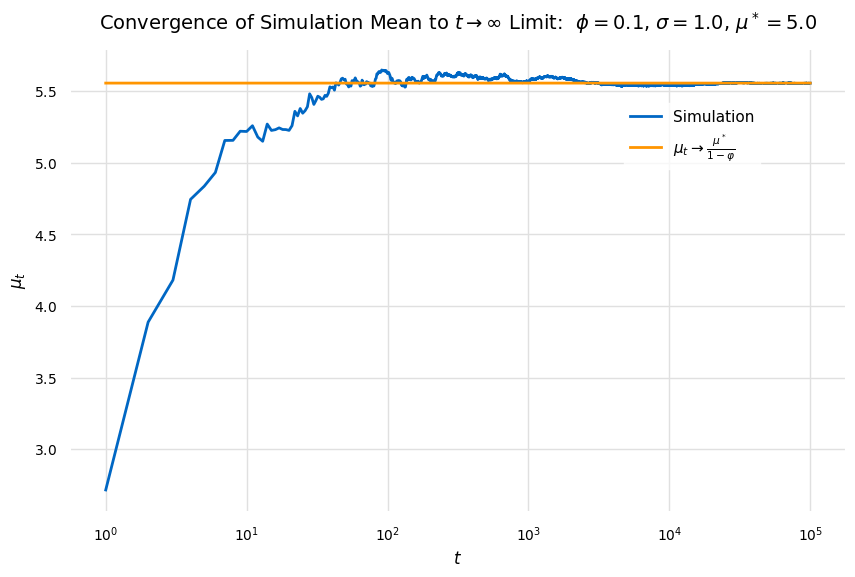

In [41]:
φ = 0.1
μ = 5.0
nsample = 100000
cumu_mean_plot(φ, σ, μ, nsample)

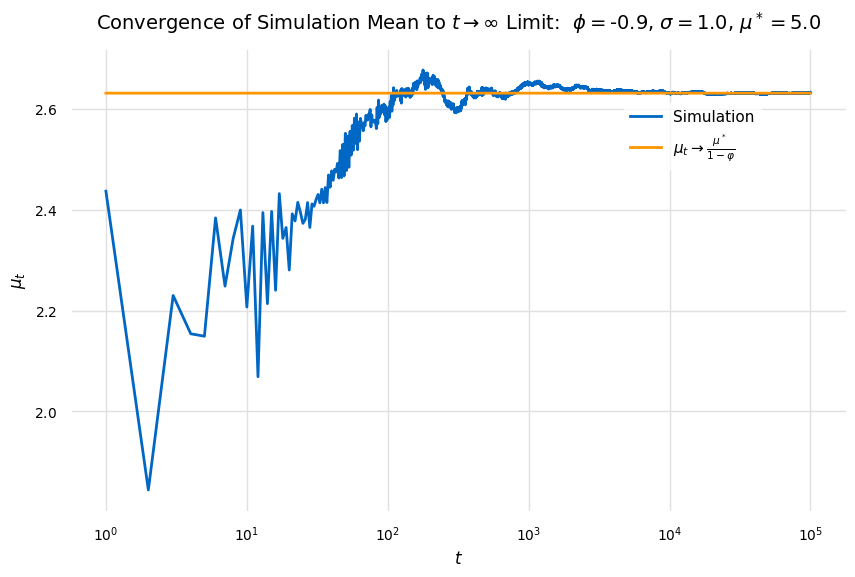

In [42]:
φ = -0.9
μ = 5.0
nsample = 100000
cumu_mean_plot(φ, σ, μ, nsample)

## Standard Deviation

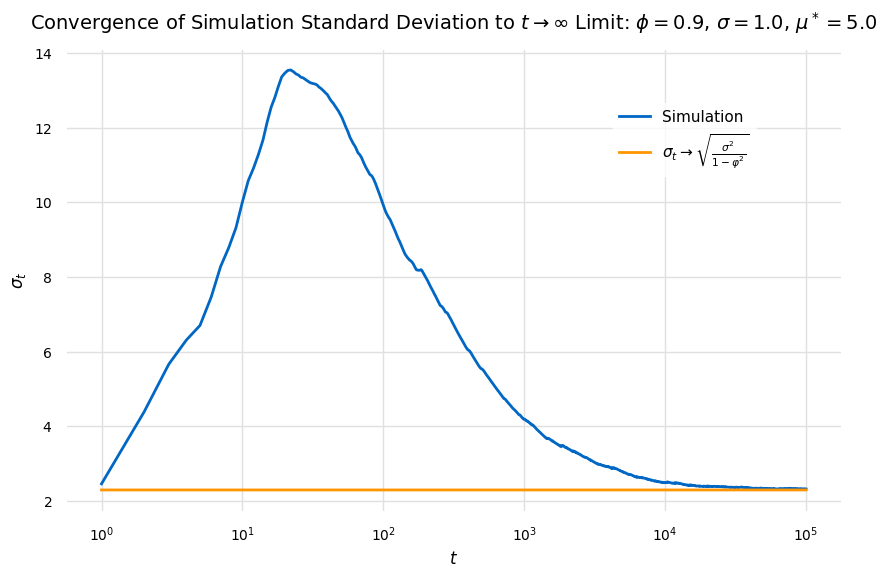

In [43]:
φ = 0.9
nsample = 100000
cumu_sd_plot(φ, σ, μ, nsample)

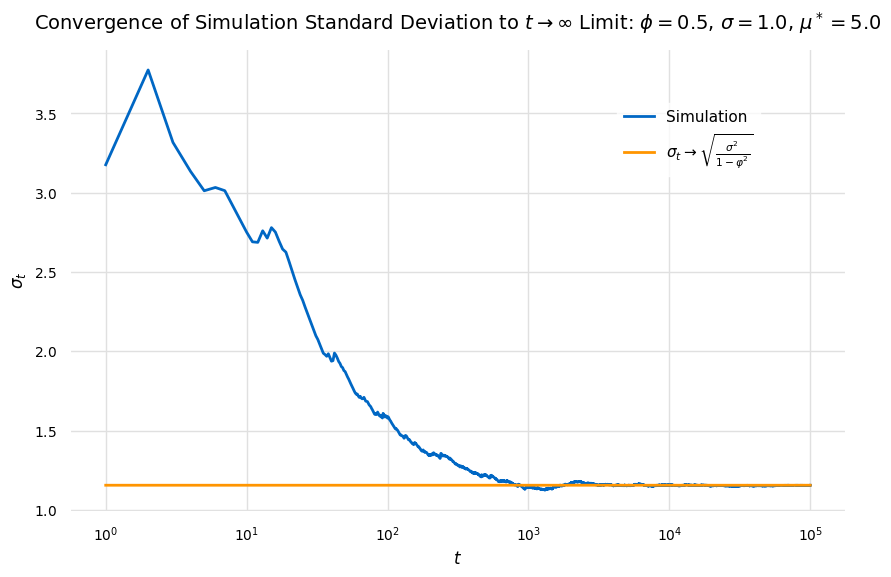

In [44]:
φ = 0.5
nsample = 100000
cumu_sd_plot(φ, σ, μ, nsample)

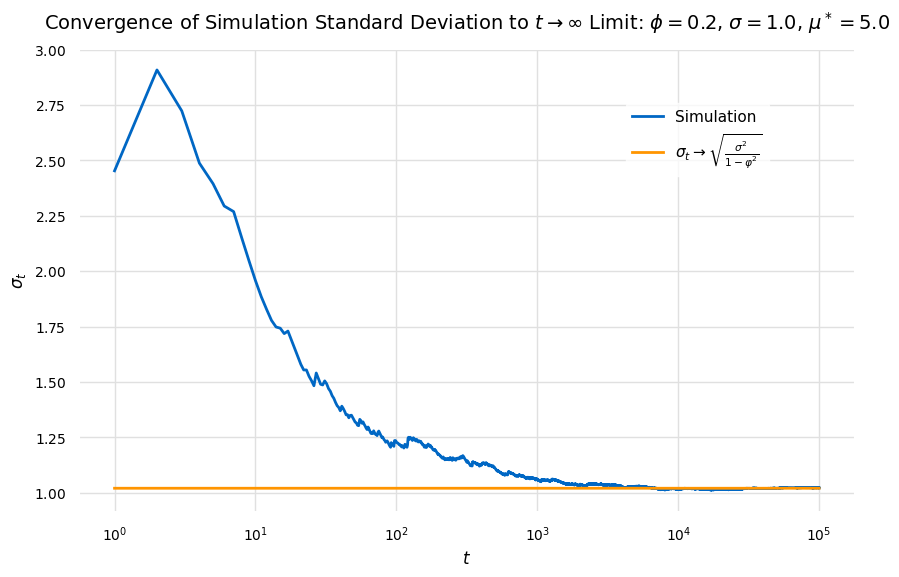

In [45]:
φ = 0.2
nsample = 100000
cumu_sd_plot(φ, σ, μ, nsample)

## Parameter Estimation

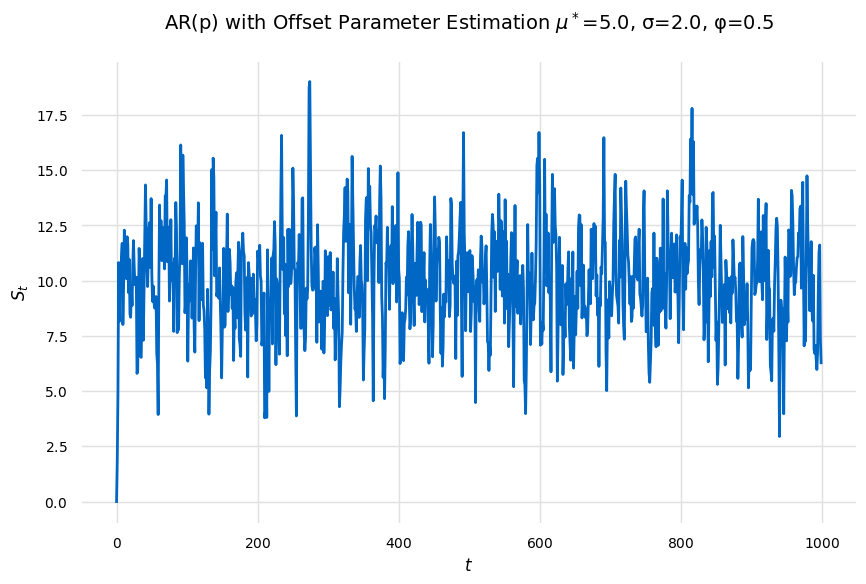

In [46]:
φ = 0.5
μ = 5.0
σ = 2.0
nsample = 1000
t, ar = arima.create_ar_offset_source(φ=[φ], σ=σ, μ=μ, npts=nsample)
title = f"AR(p) with Offset Parameter Estimation $\mu^*$={μ}, σ={σ}, φ={φ}"
curve(ar, t, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

In [47]:
result, result_model = arima.compute_ar_offset_estimate(ar, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -2113.521
Date:                Sat, 18 Jul 2026   AIC                           4233.042
Time:                        18:42:36   BIC                           4247.765
Sample:                             0   HQIC                          4238.638
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.9724      0.135     74.117      0.000       9.709      10.236
ar.L1          0.5381      0.025     21.445      0.000       0.489       0.587
sigma2         4.0101      0.171     23.474      0.000       3.675       4.345
===================================================================================
Ljung-Box (L1) (Q):                   0.21   Jarque-Bera (JB):                 3.36
Prob(Q):                              0.64   Prob(JB):                         0.19
Heteroskedasticity (H):               0.76   Skew:                             0.02
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.28
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [48]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR_OFFSET",
   "const": {
      "est": 9.972385519798161,
      "err": 0.13454976552335846,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "0e23cb92-2702-4f17-ab96-bc7a4b077657",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.538127989197751,
         "err": 0.025093304126261148,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "0e23cb92-2702-4f17-ab96-bc7a4b077657",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 4.010083676611334,
      "err": 0.1708315948779975,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "0e23

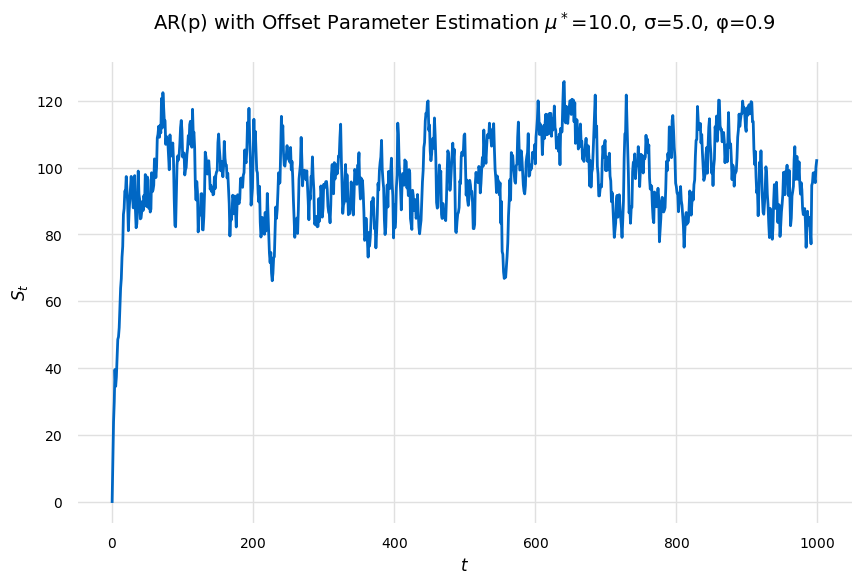

In [49]:
φ = 0.9
μ = 10.0
σ = 5.0
nsample = 1000
t, ar = arima.create_ar_offset_source(φ=[φ], σ=σ, μ=μ, npts=nsample)
title = f"AR(p) with Offset Parameter Estimation $\mu^*$={μ}, σ={σ}, φ={φ}"
curve(ar, t, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

In [50]:
result, result_model = arima.compute_ar_offset_estimate(ar, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -3058.856
Date:                Sat, 18 Jul 2026   AIC                           6123.712
Time:                        18:42:37   BIC                           6138.436
Sample:                             0   HQIC                          6129.308
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         95.2945      2.720     35.035      0.000      89.963     100.626
ar.L1          0.9428      0.005    189.838      0.000       0.933       0.952
sigma2        26.5134      1.248     21.241      0.000      24.067      28.960
===================================================================================
Ljung-Box (L1) (Q):                   0.82   Jarque-Bera (JB):                60.47
Prob(Q):                              0.36   Prob(JB):                         0.00
Heteroskedasticity (H):               0.84   Skew:                            -0.27
Prob(H) (two-sided):                  0.11   Kurtosis:                         4.08
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [51]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR_OFFSET",
   "const": {
      "est": 95.29449753319834,
      "err": 2.7199510853690683,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "de6639ed-b0fc-4998-b5f5-3a1c02567637",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.9427562342749595,
         "err": 0.00496612125469852,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "de6639ed-b0fc-4998-b5f5-3a1c02567637",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 26.513435654461865,
      "err": 1.248197375613894,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "de663

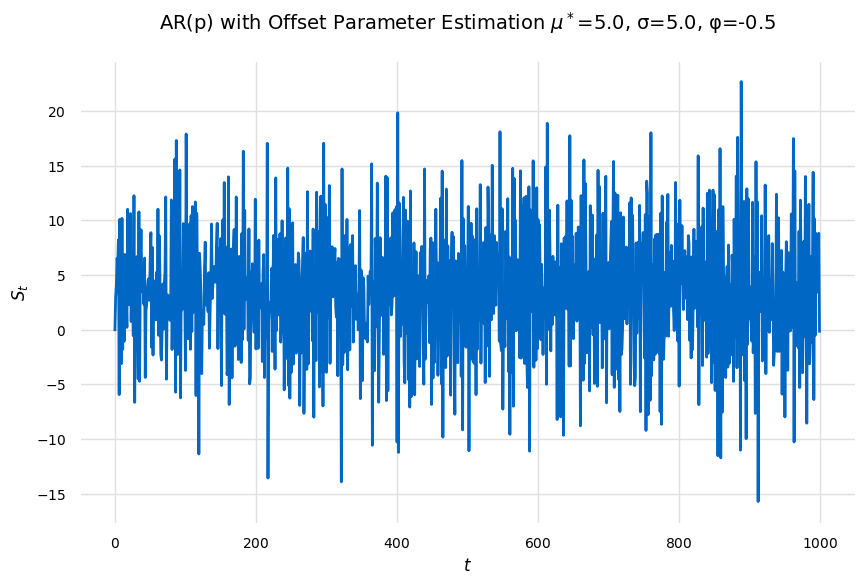

In [52]:
φ = -0.5
μ = 5.0
nsample = 1000
t, ar = arima.create_ar_offset_source(φ=[φ], σ=σ, μ=μ, npts=nsample)
title = f"AR(p) with Offset Parameter Estimation $\mu^*$={μ}, σ={σ}, φ={φ}"
curve(ar, t, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

In [53]:
result, result_model = arima.compute_ar_offset_estimate(ar, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -3040.784
Date:                Sat, 18 Jul 2026   AIC                           6087.569
Time:                        18:42:37   BIC                           6102.292
Sample:                             0   HQIC                          6093.165
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.4864      0.105     33.361      0.000       3.282       3.691
ar.L1         -0.5329      0.026    -20.783      0.000      -0.583      -0.483
sigma2        25.6199      1.210     21.179      0.000      23.249      27.991
===================================================================================
Ljung-Box (L1) (Q):                   0.46   Jarque-Bera (JB):                 1.89
Prob(Q):                              0.50   Prob(JB):                         0.39
Heteroskedasticity (H):               1.23   Skew:                            -0.04
Prob(H) (two-sided):                  0.06   Kurtosis:                         2.80
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [54]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR_OFFSET",
   "const": {
      "est": 3.486407728150594,
      "err": 0.10450640351030384,
      "est_label": "$\\hat{\\mu^*}$",
      "err_label": "$\\sigma_{\\hat{\\mu^*}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "c279ddb1-f95a-42b9-8b0a-cba182be7e60",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": -0.5328795125081028,
         "err": 0.02564006698110318,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{$\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "c279ddb1-f95a-42b9-8b0a-cba182be7e60",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 25.61993049719474,
      "err": 1.2096750019087428,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "c27